In [1]:

import os


os.chdir("../")
import torch


from environments.switchboard.switchboard import Switchboard
from rl.policies import RandomBernoulliPolicy, RandomDiscretePolicy
from environments.shape_environment.shape_env import ShapeEnv

from rl.policies import BernoulliPolicy
from rl.buffer import EpisodicBuffer


from rl.dreamer.dreamer import Dreamer
# Viszualization & Logging
from rl.viz import plot_metrics, evaluate_agent_goal_attainment
from rl.util import ExperimentLogger
from IPython.display import clear_output
from rl.dreamer.rssm import RSSM, Encoder, ImageDecoder, ImgDecoder, ImgEncoder, RSSMState, EnergyRSSM, ImageJointObservationStateEmbedding, ConvEncoder
from rl.dreamer.helper import DreamerAgent, DreamerShapeEnvPrediction



device = "cuda"
torch.set_default_device(device)



action_dim = 4
obs_dim = [3, 32, 32] # RGB images of size 32x32
num_episodes = 20000
episode_length = 20


LAT, CAT, DET = 16, 16, 256 # Dreamer latent space dimensions, deterministic hidden state as well as stochastic (latent dimensions, number of categories)

env = ShapeEnv(time_scaling=0, img_size=32, sizes=[5,10], colors=['red', 'green', 'blue'], shapes=['circle', 'triangle', 'square'], random_position=False, device=device, random_initial=True)


buffer_shapes = ( 
    {
        "step": [1],
        "observation": obs_dim,
        "action": [action_dim],
        "next_observation" : obs_dim,
        "reward": [1],
        "desired_goal": obs_dim,
        "state" : [2 * LAT * CAT + DET],
        "label_size" : [len(env.sizes_list)],
        "label_color" : [len(env.colors_list)],
        "label_shape" : [len(env.shapes_list)],
    }
)



In [2]:
from matplotlib import pyplot as plt
def train(agent, buffer, logger, num_episodes, LOG_INTERVAL = 100, train_buffer=None, render=False):
    """
        Full reinforcement learning loop to train an agent, providing
        
        - data acquisition
        - agent training
        - logging
    
        agent: dreamer based agent
        buffer: experience buffer
        train_buffer: buffer used for updating the agent. If not provided, experience buffer is used.
        goal_sampler: function to provide goals during training
        reward_function: function to compute reward given next observation and goal
    """
    print(f"Starting training for {num_episodes} episodes...")
    
    global_step = 0
    for episode in range(num_episodes):
        obs = env.reset()
        agent.dreamer.reset()

        for step in range(episode_length):
            # horizon = 1 at episode start, 0 at end
            
            action = agent.get_action(obs, None) # random policy
            next_obs, _ = env.step(lambda o: action) # turn taking, do not care about computation time
            #print(next_obs.shape)

            # NEW: update dreamer state
            agent.dreamer.state = agent.dreamer.step(action, next_obs).detach()
            state = env._get_state()

            buffer.append({ 
                'observation': obs,
                'action': action,
                "state" : agent.dreamer.state.as_subclass(torch.Tensor),
                'next_observation': next_obs,
                "label_size" : state["size_one_hot"].reshape((1,-1)),
                "label_color" : state["color_one_hot"].reshape((1,-1)),
                "label_shape" : state["shape_one_hot"].reshape((1,-1)),
            })

            obs = next_obs
            global_step += 1
 
        
        buffer.new_episode()

        # Update agent every 16 episodes
        if episode % 1 == 0:
            data = agent.update(buffer if train_buffer is None else train_buffer, step=global_step)
            data = data | agent.shape_predictor.update(buffer if train_buffer is None else train_buffer, step=global_step)
            if data:
                logger.append(episode, data)


        if (episode % LOG_INTERVAL == 0):
            log_message = f"Episode {episode}, "
            for metric in logger.get_metric_list():
                # Print the current rolling average
                avg_value = logger.get_rolling_average(logger.raw_history[metric])
                log_message += f"{metric}: {avg_value:.3f}, "
            clear_output(wait=True)
            print(log_message.rstrip(', '))

            label_msg = ""
            label_prediction = agent.shape_predictor.predict(agent.dreamer.state.deter)
            for i, name in enumerate(agent.shape_predictor.names):
                pred = label_prediction[i].probs.argmax(dim=-1).item()
                true = env._get_state()[f"{name}_one_hot"].argmax().item()
                label_msg += f"{name}  [{true} | {pred}]"
            print(label_msg)

             # visualize reconstruction:
            rec_observation = agent.dreamer.rssm.decoder(agent.dreamer.state.combined)
            real_observation = next_obs

            logger.append_tensor(episode, {"reconstruction": rec_observation, "observation" : real_observation})
            if render:
                plt.figure(figsize=(12,6))
                plt.subplot(1,2,1)
                plt.title("Real Observation")
                plt.imshow(real_observation.squeeze(0).detach().cpu().numpy().transpose(1, 2, 0)) # permute
                plt.subplot(1,2,2)
                plt.title("Reconstructed Observation")
                plt.imshow(rec_observation.squeeze(0).detach().cpu().numpy().transpose(1, 2, 0)) # permute
                plt.show()
                plt.figure()
                plot_metrics(logger, metrics=["class_shape_acc","class_color_acc","class_size_acc"])


## Vanilla Dreamer V3

Episode 0, dyn: 1.000, rep: 1.000, dyn_raw: 0.027, rep_raw: 0.027, rec_loss: 0.245, class_size_loss: 2.879, class_size_acc: 0.344, class_color_loss: 2.879, class_color_acc: 0.562, class_shape_loss: 2.879, class_shape_acc: 0.332
size  [1 | 0]color  [0 | 2]shape  [0 | 0]


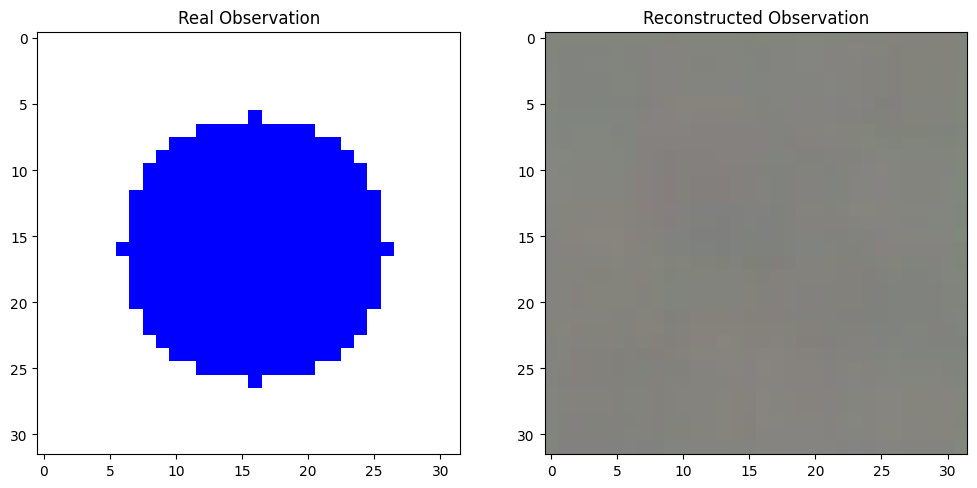

<Figure size 640x480 with 0 Axes>

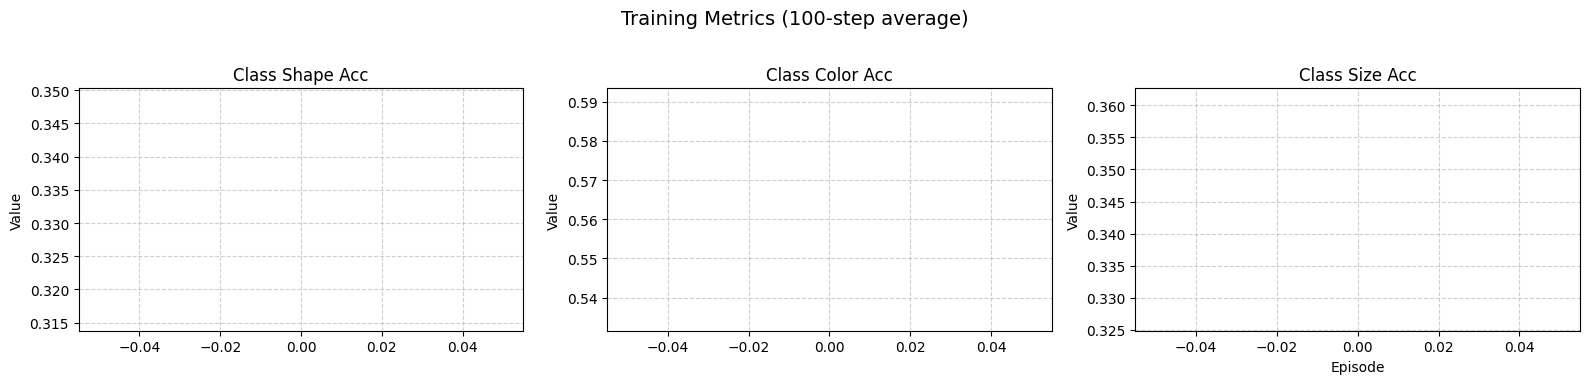

KeyboardInterrupt: 

In [3]:

img_enc = ConvEncoder(output_dim=256)
encoder = ImgEncoder(latent_img_dim=256, state_shape=DET, latent_dim=LAT, categoricals=CAT, img_enc=img_enc)#  self.decoder = Decoder(observation_shape=self.observation_space[0], latent_dim=self.latent_space[0], categoricals=self.latent_space[1], memory_dim=self.memory_dim, config=config["decoder"]) if decoder is None else decoder#
decoder = ImageDecoder(memory_dim=DET, latent=LAT, cat=CAT)# self.encoder = Encoder(observation_shape=self.observation_space[0], latent_dim=self.latent_space[0], categoricals=self.latent_space[1], memory_dim=self.memory_dim, config=config["encoder"]) if encoder is None else encoder#
rssm = RSSM(device=device, encoder=encoder, decoder=decoder, action_space=action_dim, latent_space=[LAT,CAT], sequence_model_memory_size=DET).to(device)
dreamer = Dreamer(rssm=rssm, latent_space=[LAT,CAT], sequence_model_memory_size=DET, device=device, batch_size=256, unroll_steps=16, free_bits=1.0, unimix=0.01).to(device)



buffer = EpisodicBuffer(device=device, num_episodes=2500, max_episode_length=episode_length, shapes = buffer_shapes) 
agent = DreamerAgent(dreamer=dreamer, policy=RandomDiscretePolicy(action_shape=action_dim).to(device), device=device)
shape_predictor = DreamerShapeEnvPrediction(class_sizes=[len(env.sizes_list), len(env.colors_list), len(env.shapes_list)], names=["size", "color", "shape"], DET=DET, CAT=CAT, LAT=LAT).to(device)
agent.shape_predictor = shape_predictor
logger = ExperimentLogger(log_window_size=200)
agent.buffer = buffer
buffer.clear() # clear buffer if we start a new experiment
train(agent=agent, buffer=buffer, logger=logger, num_episodes=num_episodes, LOG_INTERVAL=200, render=True)

## Energy Dreamer

Episode 0, dyn: 1.000, rep: 1.000, dyn_raw: 0.023, rep_raw: 0.023, rec_loss: 0.245, positive_loss: 0.646, negative_loss: 0.743, positive_energy: 0.096, negative_energy: 0.096, class_size_loss: 2.880, class_size_acc: 0.395, class_color_loss: 2.880, class_color_acc: 0.184, class_shape_loss: 2.880, class_shape_acc: 0.547
size  [0 | 1]color  [2 | 2]shape  [1 | 0]


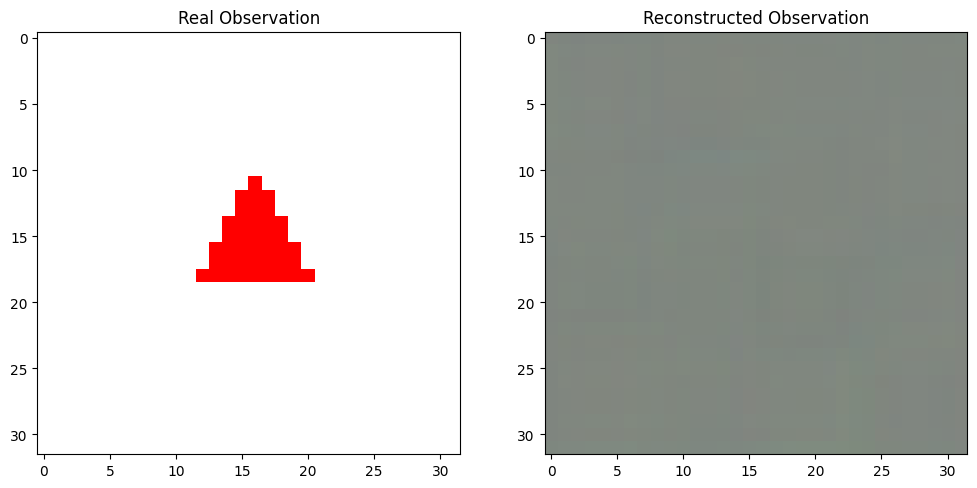

<Figure size 640x480 with 0 Axes>

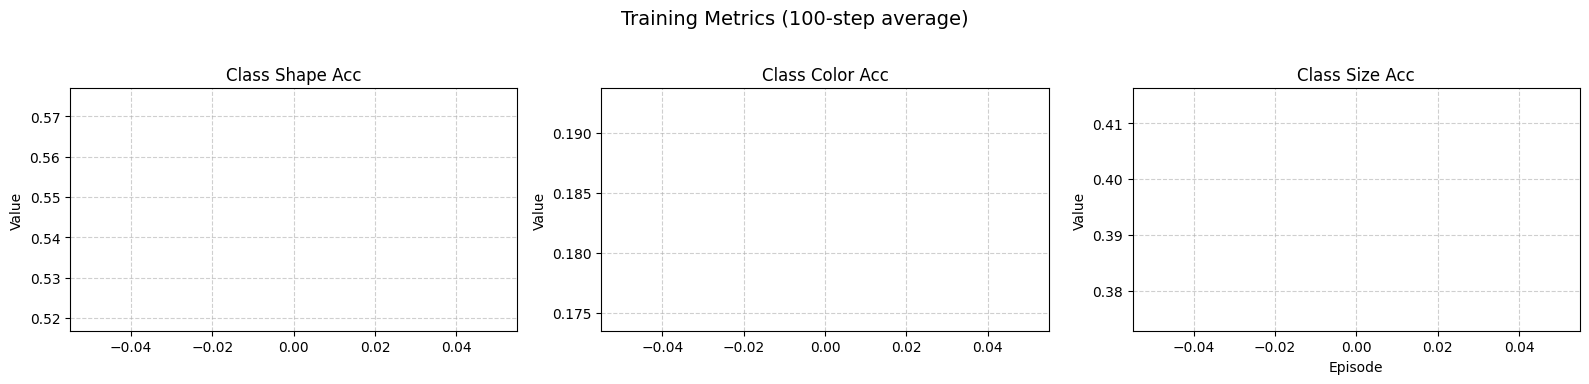

KeyboardInterrupt: 

In [ ]:

energy_img_enc = ConvEncoder(output_dim=256)
energy_encoder = ImgEncoder(latent_img_dim=256, state_shape=DET, latent_dim=LAT, categoricals=CAT, img_enc=energy_img_enc)#  self.decoder = Decoder(observation_shape=self.observation_space[0], latent_dim=self.latent_space[0], categoricals=self.latent_space[1], memory_dim=self.memory_dim, config=config["decoder"]) if decoder is None else decoder#
decoder = ImageDecoder(memory_dim=DET, latent=LAT, cat=CAT)# self.encoder = Encoder(observation_shape=self.observation_space[0], latent_dim=self.latent_space[0], categoricals=self.latent_space[1], memory_dim=self.memory_dim, config=config["encoder"]) if encoder is None else encoder#
energy_model = ImageJointObservationStateEmbedding(o_shape=256, h_shape=DET+LAT*CAT, observation_encoder=energy_img_enc).to(device)
energy_rssm = EnergyRSSM(device=device, encoder=energy_encoder, decoder=decoder, energy_model=energy_model, action_space=action_dim, latent_space=[LAT,CAT], sequence_model_memory_size=DET).to(device)
energy_dreamer = Dreamer(rssm=energy_rssm, latent_space=[LAT,CAT], sequence_model_memory_size=DET, device=device, batch_size=256, unroll_steps=16, free_bits=1.0, unimix=0.01).to(device)




energy_buffer = EpisodicBuffer(device=device, num_episodes=2500, max_episode_length=episode_length, shapes = buffer_shapes) 
energy_agent = DreamerAgent(dreamer=energy_dreamer, policy=RandomDiscretePolicy(action_shape=action_dim).to(device), device=device)
energy_shape_predictor = DreamerShapeEnvPrediction(class_sizes=[len(env.sizes_list), len(env.colors_list), len(env.shapes_list)], names=["size", "color", "shape"], DET=DET, CAT=CAT, LAT=LAT).to(device)
energy_agent.shape_predictor = energy_shape_predictor
energy_logger = ExperimentLogger(log_window_size=200)
energy_buffer.clear() # clear buffer if we start a new experiment
energy_agent.buffer = energy_buffer
train(agent=energy_agent, buffer=energy_buffer, logger=energy_logger, num_episodes=num_episodes, LOG_INTERVAL=200, render=True)

In [ ]:
# from rl.dreamer.viz import load_dreamer_models
# agent, energy_agent = load_dreamer_models()
# energy_logger = energy_agent.logger
# logger = agent.logger

## Prediction accuracy during training

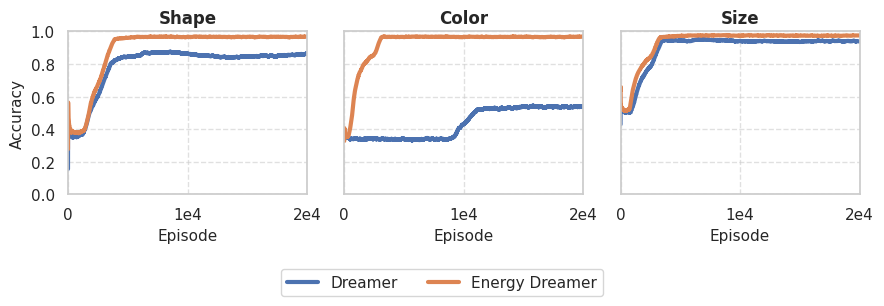

In [7]:


from rl.dreamer.viz import plot_combined_metrics_sns_single_legend

plot_combined_metrics_sns_single_legend(logger, energy_logger, titles=["Shape","Color","Size"], metrics=["class_shape_acc","class_color_acc","class_size_acc"], logger1_label="Dreamer", logger2_label="Energy Dreamer")

## Reconstruction quality

Grounding agents for 5 steps...


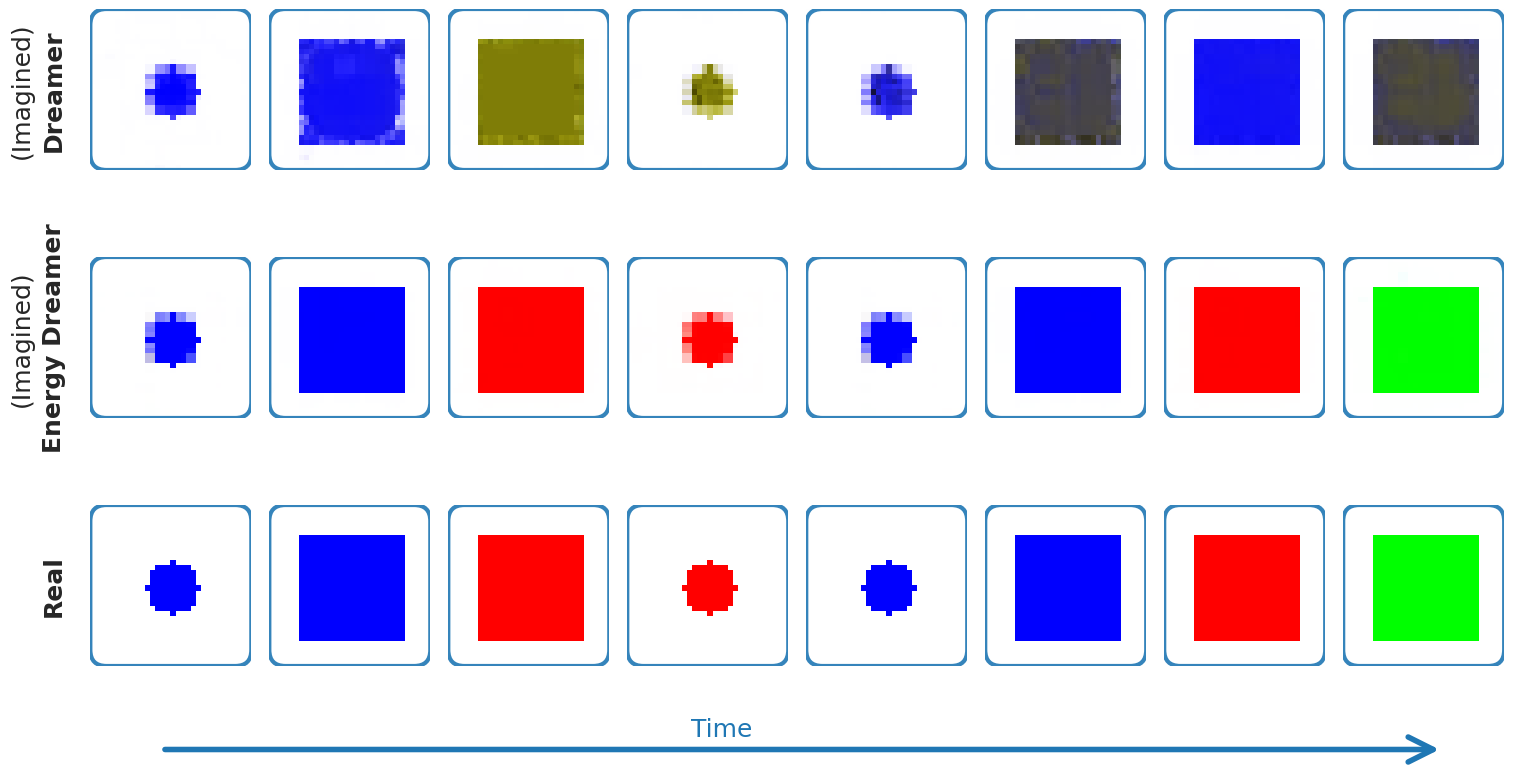

In [8]:
from rl.dreamer.viz import plot_comparison_sequence_simultaneous
plot_comparison_sequence_simultaneous(env, agent, energy_agent, device, 8, "Dreamer", "Energy Dreamer", N_grounding_steps=5)

## Prediction accuracy during imagination

Starting 100 grounding and rollout experiments...
Experiment complete. Plotting results...


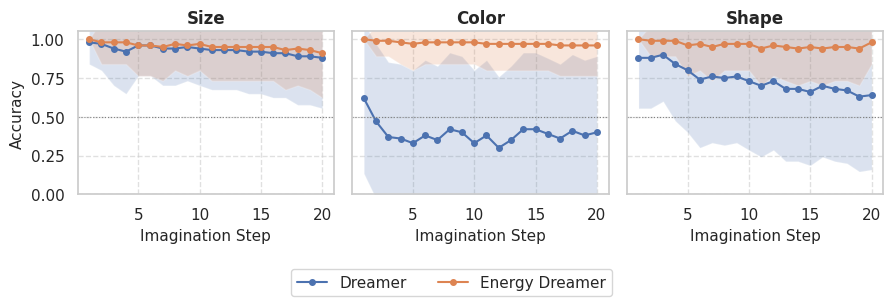

In [9]:
from rl.dreamer.viz import plot_shape_prediction_rollout_accuracy


plot_shape_prediction_rollout_accuracy(agent, energy_agent,device=device,env=env,labels=["Dreamer","Energy Dreamer"], M=100, N_grounding_steps=5, K_rollout_steps=20)

## Environment Overview

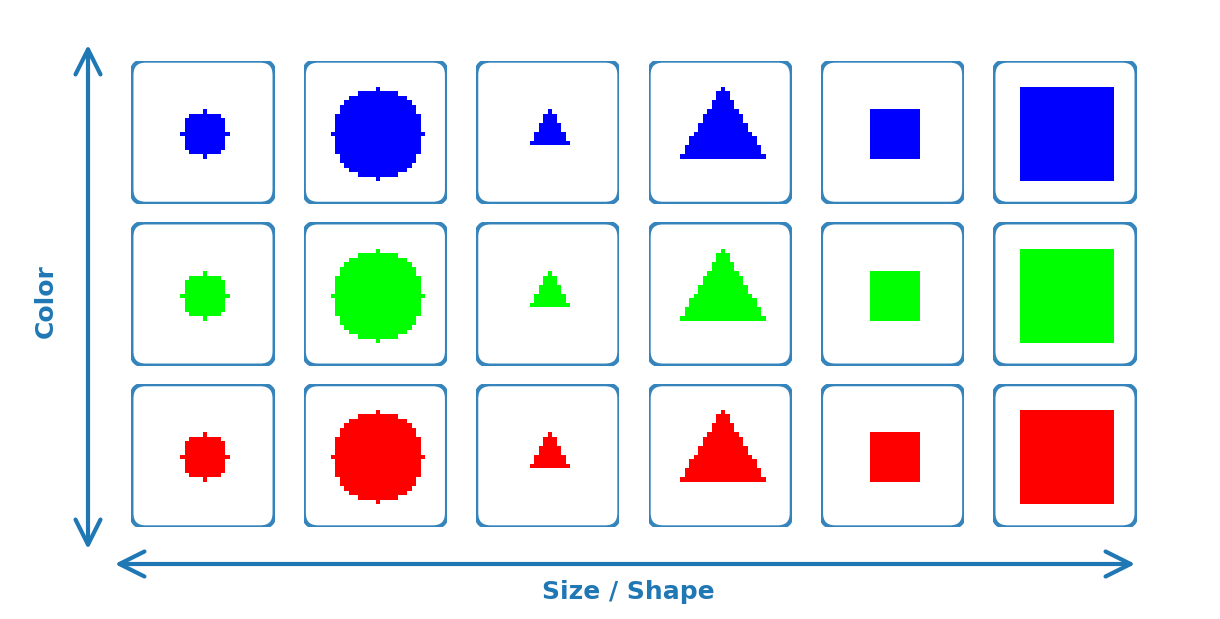

In [10]:
from rl.dreamer.viz import generate_shape_env_overview

generate_shape_env_overview(env)